# Real swell

Main method only: attention-enhanced StructBS with adaptive dip-aligned second-order TV.
Output selection uses the minimum total training loss, as in the original experiment.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from scipy.io import loadmat, savemat
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

root = Path.cwd()
if not (root / 'network.py').exists():
    root = root.parent
example_dir = root / 'real_swell'
if str(root) not in sys.path:
    sys.path.append(str(root))

from network import NoiseNetwork, set_seed

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'seismic'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(torch.cuda.get_device_name(device))
else:
    print('Using CPU')

NVIDIA RTX 4000 SFF Ada Generation


In [2]:
def clip_abs(x, q=99.0):
    return float(np.percentile(np.abs(x), q))


def show_section(ax, x, title, cmap='gray', q=99.0):
    #v = clip_abs(x, q=q)
    v=1
    im = ax.imshow(x, aspect='auto', cmap=cmap, vmin=-v, vmax=v)
    ax.set_title(title)
    ax.set_xlabel('Trace')
    ax.set_ylabel('Time sample')
    return im


def find_2d_keys(mat_dict):
    keys = []
    for key, value in mat_dict.items():
        if key.startswith('__'):
            continue
        arr = np.asarray(value)
        if arr.ndim == 2:
            keys.append((key, arr.shape, arr.dtype))
    return keys

Available 2D arrays:
  d: shape=(1536, 312), dtype=float64
  dbp: shape=(1536, 312), dtype=float64
Selected data key: dbp
Working data shape: (288, 1536)


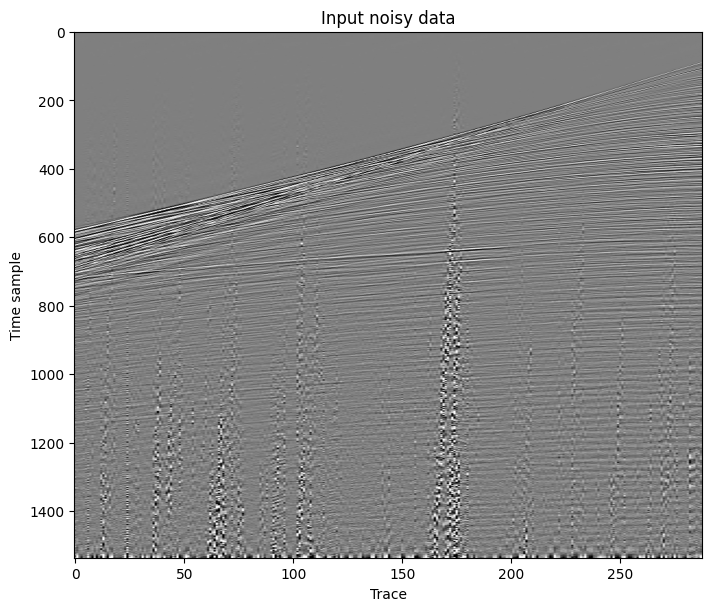

In [3]:
mat_path = example_dir / 'd_swell_real.mat'
data_key = 'dbp'
transpose_input = True
normalize_by_absmax = False

mat = loadmat(mat_path)
print('Available 2D arrays:')
for key, shape, dtype in find_2d_keys(mat):
    print(f'  {key}: shape={shape}, dtype={dtype}')

data = np.asarray(mat[data_key], dtype=np.float64)
if transpose_input:
    data = data.T

scale = np.max(np.abs(data)) + 1e-12 if normalize_by_absmax else 1.0
data = data / scale
data=data[0:288,:]

print('Selected data key:', data_key)
print('Working data shape:', data.shape)

fig, ax = plt.subplots(1, 1, figsize=(7, 6), constrained_layout=True)
show_section(ax, data.T, 'Input noisy data')
plt.show()

In [4]:
def b3(sigma):
    return np.array([
        (1.0 - sigma) * (2.0 - sigma) / 12.0,
        (2.0 + sigma) * (2.0 - sigma) / 6.0,
        (1.0 + sigma) * (2.0 + sigma) / 12.0,
    ], dtype=np.float64)


def b3d(sigma):
    return np.array([
        -((2.0 - sigma) + (1.0 - sigma)) / 12.0,
        ((2.0 - sigma) - (2.0 + sigma)) / 6.0,
        ((2.0 + sigma) + (1.0 + sigma)) / 12.0,
    ], dtype=np.float64)


def conv_allpass(data, dip, order=1):
    n1, n2 = data.shape
    nw = 1 if order == 1 else 2
    u1 = np.zeros_like(data, dtype=np.float64)
    u2 = np.zeros_like(data, dtype=np.float64)

    for i1 in range(nw, n1 - nw):
        for i2 in range(n2 - 1):
            sigma = float(np.clip(dip[i1, i2], -3.0, 3.0))
            fv = b3(sigma)
            fd = b3d(sigma)
            for k, iw in enumerate(range(-nw, nw + 1)):
                diff = data[i1 + iw, i2 + 1] - data[i1 - iw, i2]
                u1[i1, i2] += diff * fd[k]
                u2[i1, i2] += diff * fv[k]
    return u1, u2


def smooth_ratio(num, den, sigma=(4.0, 4.0), eps=1e-3):
    ratio = num / (den + eps * np.sign(den) + 1e-12)
    ratio = np.nan_to_num(ratio, nan=0.0, posinf=0.0, neginf=0.0)
    return gaussian_filter(ratio, sigma=sigma, mode='nearest')


def estimate_pwd_dip(data, niter=6, order=1, smooth_sigma=(4.0, 4.0), eps=1e-3):
    dip = np.zeros_like(data, dtype=np.float64)
    history = []
    for _ in range(niter):
        u1, u2 = conv_allpass(data, dip, order=order)
        update = smooth_ratio(-u2, u1, sigma=smooth_sigma, eps=eps)
        dip += update
        dip = np.clip(dip, -3.0, 3.0)
        history.append(float(np.linalg.norm(update) / (np.linalg.norm(dip) + 1e-12)))
    return dip, history

In [5]:
def dip_aligned_tv_second_order(x, dip_field):
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    dx = F.pad(dx, (0, 1, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1))

    tx = torch.ones_like(dip_field)
    ty = dip_field
    norm = torch.sqrt(tx * tx + ty * ty + 1e-12)
    tx = tx / norm
    ty = ty / norm

    first_directional = tx * dx + ty * dy

    dfx = first_directional[:, :, :, 1:] - first_directional[:, :, :, :-1]
    dfy = first_directional[:, :, 1:, :] - first_directional[:, :, :-1, :]
    dfx = F.pad(dfx, (0, 1, 0, 0))
    dfy = F.pad(dfy, (0, 0, 0, 1))

    second_directional = tx * dfx + ty * dfy
    return second_directional.abs().mean()


def make_dip_tensor(dip_np):
    return torch.from_numpy(dip_np).unsqueeze(0).unsqueeze(0).float().to(device)


def tv_weight_schedule(epoch, warmup=50, ramp=150, max_weight=0.2):
    if epoch < warmup:
        return 0.0
    alpha = min(1.0, (epoch - warmup) / max(ramp, 1))
    return max_weight * alpha

In [6]:
epochs = 300
lr = 1e-3
seed = 42

update_every = 50
warmup = 50
ramp = 200
max_tv_weight = 0.5
pwd_niter = 6


print(f'epochs={epochs}, lr={lr}, update_every={update_every}, warmup={warmup}, ramp={ramp}, max_tv_weight={max_tv_weight}')

epochs=300, lr=0.001, update_every=50, warmup=50, ramp=200, max_tv_weight=0.5


In [7]:
def train_adaptive_dip2(noisy_np, epochs=300, lr=1e-3, seed=42, update_every=50, warmup=50, ramp=150, max_tv_weight=0.2, pwd_niter=6):
    set_seed(seed)
    network = NoiseNetwork(1, 1, blindspot=True).to(device)
    optimizer = optim.Adam(network.parameters(), lr=lr)
    noisy_tensor = torch.from_numpy(noisy_np).unsqueeze(0).unsqueeze(0).float().to(device)

    history = {'loss': [], 'tv_weight': [], 'dip_updates': []}
    snapshots = {}
    best_pred = None
    best_loss = np.inf
    dip_tensor = None
    latest_dip = None

    for epoch in tqdm(range(epochs), desc='Adaptive dip2 TV'):
        current_tv_weight = tv_weight_schedule(epoch, warmup=warmup, ramp=ramp, max_weight=max_tv_weight)

        if epoch >= warmup and epoch % update_every == 0:
            with torch.no_grad():
                current_pred = network(noisy_tensor).detach().cpu().numpy().squeeze()
            latest_dip, _ = estimate_pwd_dip(current_pred, niter=pwd_niter, order=1, smooth_sigma=(4.0, 4.0), eps=1e-3)
            dip_tensor = make_dip_tensor(latest_dip)
            history['dip_updates'].append((int(epoch), float(np.mean(np.abs(latest_dip)))))
            snapshots[int(epoch)] = current_pred.copy()

        optimizer.zero_grad()
        prediction = network(noisy_tensor)
        data_loss = F.l1_loss(prediction, noisy_tensor)

        if dip_tensor is None or current_tv_weight == 0.0:
            reg_loss = torch.zeros((), device=device, dtype=prediction.dtype)
        else:
            reg_loss = dip_aligned_tv_second_order(prediction, dip_tensor)

        total_loss = data_loss + current_tv_weight * reg_loss
        total_loss.backward()
        optimizer.step()

        pred_np = prediction.detach().cpu().numpy().squeeze()
        history['loss'].append(float(total_loss.item()))
        history['tv_weight'].append(float(current_tv_weight))

        if total_loss.item() < best_loss:
            best_loss = float(total_loss.item())
            best_pred = pred_np.copy()

    return best_pred, history, latest_dip, snapshots


result, history, final_dip, snapshots = train_adaptive_dip2(
    noisy_np=data,
    epochs=epochs,
    lr=lr,
    seed=seed,
    update_every=update_every,
    warmup=warmup,
    ramp=ramp,
    max_tv_weight=max_tv_weight,
    pwd_niter=pwd_niter,
)

Adaptive dip2 TV:   0%|          | 0/300 [00:00<?, ?it/s]

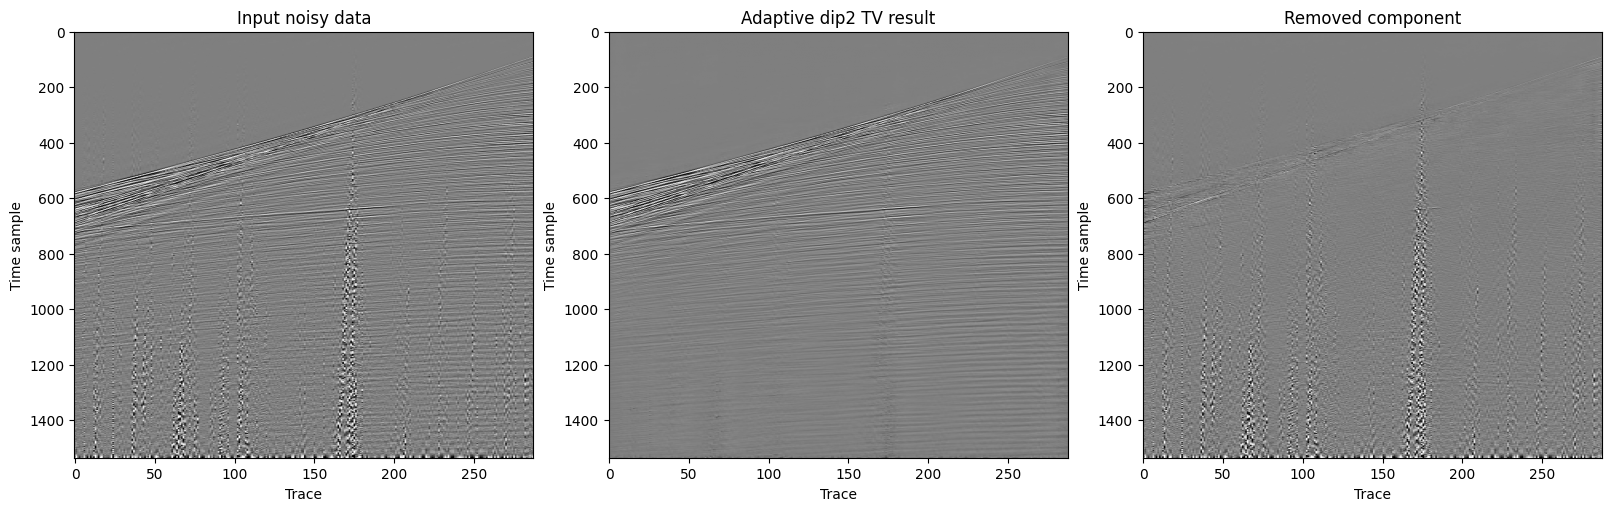

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
show_section(axes[0], data.T, 'Input noisy data')
show_section(axes[1], result.T, 'Adaptive dip2 TV result')
show_section(axes[2], (data - result).T, 'Removed component')
plt.show()

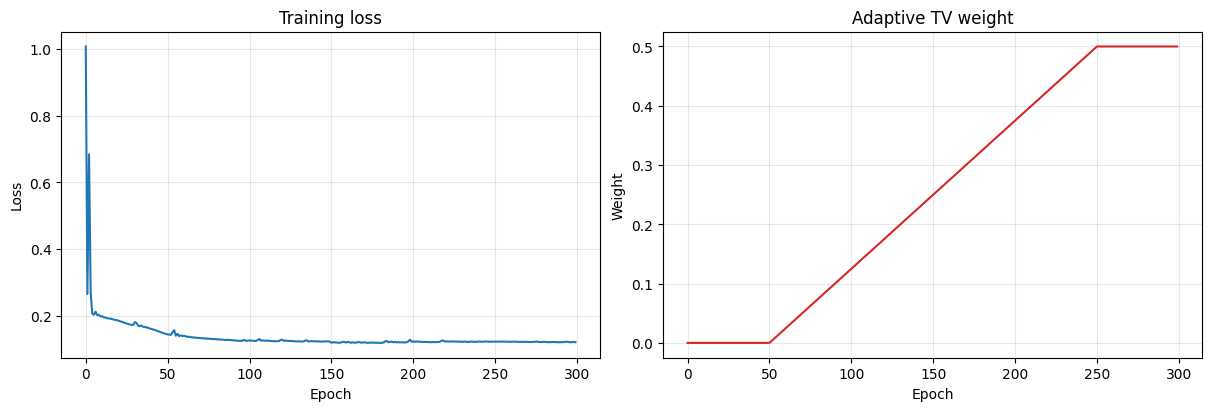

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(history['loss'])
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['tv_weight'], color='tab:red')
axes[1].set_title('Adaptive TV weight')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weight')
axes[1].grid(True, alpha=0.3)

plt.show()

In [12]:
from scipy.io import savemat
output_dir = example_dir / 'outputs'
output_dir.mkdir(exist_ok=True)
savemat(output_dir / 'denoised.mat', {'dr': result.T, 'removed': (data-result).T, 'loss': history['loss']})
